# Comparing Scenarios

Comparing several background scenarios - different premise pathways, different
IAM models, "what if we get PkBudg500 instead of Base" - is one of the most
common things to do with a `TimexLCA`. Sections 1-5 build a small dummy system
(no ecoinvent or premise needed) and walk through the pieces that make that
comparison straightforward:

1. **`representative_time` metadata** - map background databases to points in
   time without hand-writing `database_dates`.
2. **`scenario={...}`** - select one background scenario when a project holds
   several, with a clear error when the choice is ambiguous.
3. **`UnmappedDatabaseError`** - a named, actionable error when the graph
   traversal reaches a database nobody told `TimexLCA` about.
4. **`TimexLCASettings` and `TimexLCA.run()`** - one object that carries a
   whole calculation, and can be re-run with different knobs without paying
   for the static LCA twice.
5. **`TimexLCA.compare()`** - run a list of `TimexLCASettings` and get back a
   table with everything worth comparing.

Sections 6-7 then follow the same workflow where it actually matters: building
the background databases with premise, and running `TimexLCASettings` on a
real ecoinvent + premise project. Section 6 is illustrative only (real
credentials and tens of minutes needed); section 7 ran against this author's
own project (`ei312_REMIND_EU`, ecoinvent 3.12 + REMIND-EU SSP2-NDC), so its
outputs are kept as-is rather than reproducible by re-running this notebook
elsewhere.


## Setup: a system with two possible futures

The story: `A` draws 10 kWh of electricity to make one unit of product.
The grid decarbonizes over time, but *how much* by 2030 depends on which IAM
pathway materializes - `SSP2-Base` barely improves on 2020, `SSP2-PkBudg500`
cuts emissions to a fifth. We register three background databases and one
foreground, and tell `bw_timex` what each one represents via
`set_database_metadata` instead of writing out `database_dates` by hand -
this is exactly what databases exported by premise >= 2.4.9.2 already carry
themselves.

In [1]:
import bw2data as bd

from bw_timex import TimexLCA, set_database_metadata

bd.projects.set_current("scenario_comparison_with_timex")

bd.Database("biosphere").write(
    {
        ("biosphere", "CO2"): {"type": "emission", "name": "CO2"},
    }
)

bd.Database("background_2020").write(
    {
        ("background_2020", "elec"): {
            "name": "electricity",
            "location": "somewhere",
            "reference product": "electricity",
            "unit": "kWh",
            "exchanges": [
                {"amount": 1, "type": "production", "input": ("background_2020", "elec")},
                {"amount": 1.0, "type": "biosphere", "input": ("biosphere", "CO2")},
            ],
        },
    }
)

bd.Database("background_2030_ssp2base").write(
    {
        ("background_2030_ssp2base", "elec"): {
            "name": "electricity",
            "location": "somewhere",
            "reference product": "electricity",
            "unit": "kWh",
            "exchanges": [
                {"amount": 1, "type": "production", "input": ("background_2030_ssp2base", "elec")},
                {"amount": 0.8, "type": "biosphere", "input": ("biosphere", "CO2")},
            ],
        },
    }
)

bd.Database("background_2030_ssp2pkbudg500").write(
    {
        ("background_2030_ssp2pkbudg500", "elec"): {
            "name": "electricity",
            "location": "somewhere",
            "reference product": "electricity",
            "unit": "kWh",
            "exchanges": [
                {
                    "amount": 1,
                    "type": "production",
                    "input": ("background_2030_ssp2pkbudg500", "elec"),
                },
                {"amount": 0.2, "type": "biosphere", "input": ("biosphere", "CO2")},
            ],
        },
    }
)

bd.Database("foreground").write(
    {
        ("foreground", "A"): {
            "name": "A",
            "location": "somewhere",
            "reference product": "A",
            "exchanges": [
                {"amount": 1, "type": "production", "input": ("foreground", "A")},
                {"amount": 10, "type": "technosphere", "input": ("background_2020", "elec")},
            ],
        },
    }
)

for db in bd.databases:
    bd.Database(db).process()

method = ("GWP", "example")
bd.Method(method).write([(("biosphere", "CO2"), 1)])

demand = {("foreground", "A"): 1}


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 12018.06it/s]

21:01:14+0200 [info     ] Vacuuming database            


21:01:14+0200 [warning  ] Not able to determine geocollections for all datasets. This database is not ready for regionalization.


  0%|          | 0/1 [00:00<?, ?it/s]

...

21:01:14+0200 [info     ] Vacuuming database            


21:01:14+0200 [warning  ] Not able to determine geocollections for all datasets. This database is not ready for regionalization.


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 16980.99it/s]

21:01:14+0200 [info     ] Vacuuming database            


The foreground exchange points at `background_2020` as its nominal
supplier - `bw_timex` relinks it to whichever vintage (or blend of vintages)
is time-appropriate once it knows what each database represents. That's the
next step:

In [2]:
from datetime import datetime

set_database_metadata("background_2020", representative_time=datetime(2020, 1, 1))
set_database_metadata("foreground", representative_time="dynamic")

TimexLCA(demand, method).base_score  # only one vintage so far: no ambiguity

2026-08-23 21:01:14.375 | INFO     | bw_timex.timex_lca:__init__:275 - Initializing TimexLCA object...


2026-08-23 21:01:14.375 | INFO     | bw_timex.timex_lca:__init__:305 - Calculating base LCA...


2026-08-23 21:01:14.383 | INFO     | bw_timex.timex_lca:__init__:322 - Collecting node infos...


2026-08-23 21:01:14.384 | INFO     | bw_timex.timex_lca:__init__:334 - Loading node metadata from 2 database(s)...


2026-08-23 21:01:14.385 | INFO     | bw_timex.timex_lca:__init__:371 - TimexLCA initialized.


10.0

Nothing but `set_database_metadata` calls were needed - no
`database_dates` dict was passed. Now we register the two competing 2030
databases, each declaring which pathway it belongs to:

In [3]:
set_database_metadata(
    "background_2030_ssp2base",
    representative_time=datetime(2030, 1, 1),
    pathway="SSP2-Base",
)
set_database_metadata(
    "background_2030_ssp2pkbudg500",
    representative_time=datetime(2030, 1, 1),
    pathway="SSP2-PkBudg500",
)

try:
    TimexLCA(demand, method)
except ValueError as error:
    print(error)

2026-08-23 21:01:14.391 | INFO     | bw_timex.timex_lca:__init__:275 - Initializing TimexLCA object...


Several background scenarios found in this project:
  pathway=SSP2-Base: background_2030_ssp2base
  pathway=SSP2-PkBudg500: background_2030_ssp2pkbudg500
Select one, e.g. scenario={'pathway': '...'}, or map the databases explicitly with `database_dates`.


`TimexLCA` found two scenario databases and refused to guess which one
you meant, rather than silently picking one. Narrowing down with `scenario`
resolves it - and only the databases that actually declare the filtered key
are excluded, so `background_2020` (which declares no `pathway` at all) stays
available in both cases:

In [4]:
from dataclasses import replace

tlca_base = TimexLCA(demand, method, scenario={"pathway": "SSP2-Base"})
tlca_pkbudg500 = TimexLCA(demand, method, scenario={"pathway": "SSP2-PkBudg500"})

print("SSP2-Base resolves to:     ", tlca_base.database_dates)
print("SSP2-PkBudg500 resolves to:", tlca_pkbudg500.database_dates)

2026-08-23 21:01:14.394 | INFO     | bw_timex.timex_lca:__init__:275 - Initializing TimexLCA object...


2026-08-23 21:01:14.395 | INFO     | bw_timex.timex_lca:__init__:305 - Calculating base LCA...


2026-08-23 21:01:14.399 | INFO     | bw_timex.timex_lca:__init__:322 - Collecting node infos...


2026-08-23 21:01:14.400 | INFO     | bw_timex.timex_lca:__init__:334 - Loading node metadata from 3 database(s)...


2026-08-23 21:01:14.401 | INFO     | bw_timex.timex_lca:__init__:371 - TimexLCA initialized.


...

2026-08-23 21:01:14.402 | INFO     | bw_timex.timex_lca:__init__:305 - Calculating base LCA...


2026-08-23 21:01:14.407 | INFO     | bw_timex.timex_lca:__init__:322 - Collecting node infos...


2026-08-23 21:01:14.408 | INFO     | bw_timex.timex_lca:__init__:334 - Loading node metadata from 3 database(s)...


2026-08-23 21:01:14.408 | INFO     | bw_timex.timex_lca:__init__:371 - TimexLCA initialized.


SSP2-Base resolves to:      {'background_2020': datetime.datetime(2020, 1, 1, 0, 0), 'background_2030_ssp2base': datetime.datetime(2030, 1, 1, 0, 0), 'foreground': 'dynamic'}
SSP2-PkBudg500 resolves to: {'background_2020': datetime.datetime(2020, 1, 1, 0, 0), 'background_2030_ssp2pkbudg500': datetime.datetime(2030, 1, 1, 0, 0), 'foreground': 'dynamic'}


## `UnmappedDatabaseError`: a named error for an unmapped database

Suppose `A` is modified to also draw from a database nobody has told
`bw_timex` about yet - a stray input, or a database added after the rest of
the model was built. The graph traversal reaches it during `build_timeline()`
and needs to know what it represents:

In [5]:
bd.Database("unmapped_extra").write(
    {
        ("unmapped_extra", "X"): {
            "name": "X",
            "location": "somewhere",
            "reference product": "X",
            "exchanges": [
                {"amount": 1, "type": "production", "input": ("unmapped_extra", "X")},
                {"amount": 4.0, "type": "biosphere", "input": ("biosphere", "CO2")},
            ],
        },
    }
)

bd.Database("foreground").write(
    {
        ("foreground", "A"): {
            "name": "A",
            "location": "somewhere",
            "reference product": "A",
            "exchanges": [
                {"amount": 1, "type": "production", "input": ("foreground", "A")},
                {"amount": 10, "type": "technosphere", "input": ("background_2020", "elec")},
            ],
        },
        ("foreground", "A2"): {
            "name": "A2",
            "location": "somewhere",
            "reference product": "A2",
            "exchanges": [
                {"amount": 1, "type": "production", "input": ("foreground", "A2")},
                {"amount": 10, "type": "technosphere", "input": ("background_2020", "elec")},
                {"amount": 1, "type": "technosphere", "input": ("unmapped_extra", "X")},
            ],
        },
    }
)
for db in bd.databases:
    bd.Database(db).process()

from bw_timex import UnmappedDatabaseError

tlca_a2 = TimexLCA(
    {("foreground", "A2"): 1}, method, scenario={"pathway": "SSP2-Base"}
)
try:
    tlca_a2.build_timeline()
except UnmappedDatabaseError as error:
    print(error)

21:01:14+0200 [warning  ] Not able to determine geocollections for all datasets. This database is not ready for regionalization.


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 32263.88it/s]

21:01:14+0200 [info     ] Vacuuming database            


21:01:14+0200 [warning  ] Not able to determine geocollections for all datasets. This database is not ready for regionalization.


...

2026-08-23 21:01:14.467 | INFO     | bw_timex.timex_lca:build_timeline:959 - Creating activity time mapping...


2026-08-23 21:01:14.467 | INFO     | bw_timex.timeline_builder:__init__:113 - Traversing supply chain graph...


2026-08-23 21:01:14.471 | INFO     | bw_timex.timeline_builder:build_timeline:184 - Building timeline...


Starting graph traversal
Calculation count: 2


The graph traversal reached processes in database(s) that are not mapped to a point in time: 'unmapped_extra' (e.g. 'X'). `bw_timex` places every traversed process in time via its database, and only the database(s) holding the functional unit are treated as 'dynamic' automatically, so a foreground split across several databases has to mark the other ones itself.
If 'unmapped_extra' is part of your foreground, mark it as dynamic:
    bw_timex.set_database_metadata('unmapped_extra', representative_time='dynamic')
If it represents a point in time, give it that date instead:
    bw_timex.set_database_metadata('unmapped_extra', representative_time=datetime(2030, 1, 1))
Databases mapped for this calculation: ['background_2020', 'background_2030_ssp2base', 'foreground']. When passing `database_dates` explicitly, it must list every database the traversal reaches.

The error names the database and an affected process, rather than the
bare `KeyError` on a node id this used to surface as. One `set_database_metadata`
call fixes it - here `unmapped_extra` is a second source that's always
current, so `"dynamic"` is the right answer, same as the foreground:

In [6]:
set_database_metadata("unmapped_extra", representative_time="dynamic")

tlca_a2 = TimexLCA(
    {("foreground", "A2"): 1}, method, scenario={"pathway": "SSP2-Base"}
)
tlca_a2.build_timeline()
print("resolved without error")

2026-08-23 21:01:14.526 | INFO     | bw_timex.timex_lca:__init__:275 - Initializing TimexLCA object...


2026-08-23 21:01:14.526 | INFO     | bw_timex.timex_lca:__init__:305 - Calculating base LCA...


2026-08-23 21:01:14.532 | INFO     | bw_timex.timex_lca:__init__:322 - Collecting node infos...


2026-08-23 21:01:14.534 | INFO     | bw_timex.timex_lca:__init__:334 - Loading node metadata from 4 database(s)...


2026-08-23 21:01:14.534 | INFO     | bw_timex.timex_lca:__init__:371 - TimexLCA initialized.


...

2026-08-23 21:01:14.536 | INFO     | bw_timex.timex_lca:build_timeline:959 - Creating activity time mapping...


2026-08-23 21:01:14.536 | INFO     | bw_timex.timeline_builder:__init__:113 - Traversing supply chain graph...


2026-08-23 21:01:14.540 | INFO     | bw_timex.timeline_builder:build_timeline:184 - Building timeline...


Starting graph traversal
Calculation count: 2


resolved without error

## `TimexLCASettings` and `TimexLCA.run()`

`TimexLCASettings` holds everything one calculation needs - the demand,
the method, the background selection, and every timeline/LCI/LCIA option - so
one object is also the record of what was run. `TimexLCA.from_settings(...)`
builds the object, and `.run()` executes `build_timeline()` -> `lci()` ->
`static_lcia()` -> `dynamic_lcia()` in one call.

In [7]:
from bw_timex import TimexLCASettings

settings = TimexLCASettings(
    demand=demand,
    method=method,
    scenario={"pathway": "SSP2-Base"},
    starting_datetime=datetime(2030, 6, 1),
    interpolation_type="nearest",  # pin to one vintage, no blending, for a clean number
    dynamic_lcia_enabled=False,
    label="SSP2-Base, 2030",
)

tlca = TimexLCA.from_settings(settings).run()
tlca.static_score  # 10 kWh x 0.8 kg CO2/kWh

2026-08-23 21:01:14.552 | INFO     | bw_timex.timex_lca:__init__:275 - Initializing TimexLCA object...


2026-08-23 21:01:14.553 | INFO     | bw_timex.timex_lca:__init__:305 - Calculating base LCA...


2026-08-23 21:01:14.559 | INFO     | bw_timex.timex_lca:__init__:322 - Collecting node infos...


2026-08-23 21:01:14.561 | INFO     | bw_timex.timex_lca:__init__:334 - Loading node metadata from 4 database(s)...


2026-08-23 21:01:14.561 | INFO     | bw_timex.timex_lca:__init__:371 - TimexLCA initialized.


...

2026-08-23 21:01:14.589 | INFO     | bw_timex.timex_lca:run:560 - Step 3/4: Calculating static LCIA...


2026-08-23 21:01:14.590 | INFO     | bw_timex.timex_lca:run:578 - Step 4/4: Skipping dynamic LCIA (disabled).


2026-08-23 21:01:14.590 | INFO     | bw_timex.timex_lca:run:580 - TimexLCA.run() completed successfully.


Starting graph traversal
Calculation count: 1


8.00000011920929

`run()` can be called again on the same object - either with a fresh
`TimexLCASettings`, or with individual overrides that leave both the passed
settings and the object's own settings untouched:

In [8]:
base_lca_id = id(tlca.base_lca)

tlca.run(starting_datetime=datetime(2020, 6, 1))  # same demand/method, different year
print("2020 score:", tlca.static_score, "  (10 kWh x 1.0 kg CO2/kWh)")
print("base LCA reused:", id(tlca.base_lca) == base_lca_id)

print("settings.starting_datetime is still:", settings.starting_datetime)

2026-08-23 21:01:14.593 | INFO     | bw_timex.timex_lca:run:529 - Starting TimexLCA.run() pipeline...


2026-08-23 21:01:14.593 | INFO     | bw_timex.timex_lca:run:536 - Step 1/4: Building timeline...


2026-08-23 21:01:14.594 | INFO     | bw_timex.timex_lca:build_timeline:938 - No edge filter function provided. Skipping all edges in background databases.


2026-08-23 21:01:14.594 | INFO     | bw_timex.timex_lca:build_timeline:959 - Creating activity time mapping...


2026-08-23 21:01:14.594 | INFO     | bw_timex.timeline_builder:__init__:113 - Traversing supply chain graph...


...

2026-08-23 21:01:14.614 | INFO     | bw_timex.timex_lca:lci:1139 - Calculating dynamic inventory...


2026-08-23 21:01:14.620 | INFO     | bw_timex.timex_lca:run:560 - Step 3/4: Calculating static LCIA...


2026-08-23 21:01:14.621 | INFO     | bw_timex.timex_lca:run:578 - Step 4/4: Skipping dynamic LCIA (disabled).


2026-08-23 21:01:14.621 | INFO     | bw_timex.timex_lca:run:580 - TimexLCA.run() completed successfully.


2020 score: 10.0   (10 kWh x 1.0 kg CO2/kWh)
base LCA reused: True
settings.starting_datetime is still: 2030-06-01 00:00:00


A changed demand or method is different: it invalidates the static LCA,
so `run()` recalculates it - but the background databases, the node proxies,
and the caches built from them are untouched, since none of that depends on
the demand:

In [9]:
tlca.run(demand={("foreground", "A"): 2}, starting_datetime=datetime(2030, 6, 1))
print("doubled demand score:", tlca.static_score)
print("base LCA rebuilt:", id(tlca.base_lca) != base_lca_id)

2026-08-23 21:01:14.624 | INFO     | bw_timex.timex_lca:run:529 - Starting TimexLCA.run() pipeline...


2026-08-23 21:01:14.624 | INFO     | bw_timex.timex_lca:_rebuild_base_lca:447 - Demand or method changed; recalculating base LCA...


2026-08-23 21:01:14.630 | INFO     | bw_timex.timex_lca:run:536 - Step 1/4: Building timeline...


2026-08-23 21:01:14.630 | INFO     | bw_timex.timex_lca:build_timeline:938 - No edge filter function provided. Skipping all edges in background databases.


2026-08-23 21:01:14.631 | INFO     | bw_timex.timex_lca:build_timeline:959 - Creating activity time mapping...


...

2026-08-23 21:01:14.651 | INFO     | bw_timex.timex_lca:lci:1139 - Calculating dynamic inventory...


2026-08-23 21:01:14.656 | INFO     | bw_timex.timex_lca:run:560 - Step 3/4: Calculating static LCIA...


2026-08-23 21:01:14.656 | INFO     | bw_timex.timex_lca:run:578 - Step 4/4: Skipping dynamic LCIA (disabled).


2026-08-23 21:01:14.656 | INFO     | bw_timex.timex_lca:run:580 - TimexLCA.run() completed successfully.


doubled demand score: 16.00000023841858
base LCA rebuilt: True


Changing the background is the one thing `run()` refuses - the
databases fix the columns of the time-explicit matrices, so a different
`scenario` or `database_dates` needs its own object:

In [10]:
try:
    tlca.run(scenario={"pathway": "SSP2-PkBudg500"})
except ValueError as error:
    print(error)

`scenario` selects the background databases, which fix the columns of the time-explicit matrices, so it cannot change between runs of one TimexLCA (this one was built with scenario={'pathway': 'SSP2-Base'}). Build another TimexLCA for it, or pass both settings to TimexLCA.compare(), which does that for you.


## `TimexLCA.compare()`: the scenario grid in one call

This is where scenario comparison actually lives: `compare()` takes a
list of `TimexLCASettings`, builds one `TimexLCA` per *distinct background*,
runs every calculation that shares a background on that one object, and
returns a `ComparisonResult`. Its `summary` is a `DataFrame` with one row per
calculation - not just the scores, but the settings behind them, so the table
is itself the reproducibility record.

In [11]:
base = TimexLCASettings(
    demand=demand,
    method=method,
    starting_datetime=datetime(2030, 6, 1),
    interpolation_type="nearest",
    dynamic_lcia_enabled=False,
)

comparison = TimexLCA.compare(
    [
        replace(base, scenario={"pathway": "SSP2-Base"}, label="SSP2-Base"),
        replace(base, scenario={"pathway": "SSP2-PkBudg500"}, label="SSP2-PkBudg500"),
    ]
)

comparison.summary[["label", "static_score", "scenario_pathway", "n_databases", "timeline_rows", "runtime_s"]]

2026-08-23 21:01:14.662 | INFO     | bw_timex.timex_lca:__init__:275 - Initializing TimexLCA object...


2026-08-23 21:01:14.663 | INFO     | bw_timex.timex_lca:__init__:305 - Calculating base LCA...


2026-08-23 21:01:14.669 | INFO     | bw_timex.timex_lca:__init__:322 - Collecting node infos...


2026-08-23 21:01:14.671 | INFO     | bw_timex.timex_lca:__init__:334 - Loading node metadata from 4 database(s)...


2026-08-23 21:01:14.671 | INFO     | bw_timex.timex_lca:__init__:371 - TimexLCA initialized.


...

2026-08-23 21:01:14.727 | INFO     | bw_timex.timex_lca:lci:1139 - Calculating dynamic inventory...


2026-08-23 21:01:14.732 | INFO     | bw_timex.timex_lca:run:560 - Step 3/4: Calculating static LCIA...


2026-08-23 21:01:14.733 | INFO     | bw_timex.timex_lca:run:578 - Step 4/4: Skipping dynamic LCIA (disabled).


2026-08-23 21:01:14.733 | INFO     | bw_timex.timex_lca:run:580 - TimexLCA.run() completed successfully.


,label,static_score,scenario_pathway,n_databases,timeline_rows,runtime_s
0,SSP2-Base,8.0,SSP2-Base,4,2,0.025782
1,SSP2-PkBudg500,2.0,SSP2-PkBudg500,4,2,0.026322


That's the score comparison. But `summary` carries a lot more than
just `static_score` - every knob the calculation ran with, so nothing about
*how* a number was produced has to be remembered separately:

In [12]:
comparison.summary.columns.tolist()

['label',
 'base_score',
 'static_score',
 'dynamic_score',
 'scenario_pathway',
 'demand',
 'method',
 'database_dates',
 'n_databases',
 'starting_datetime',
 'temporal_grouping',
 'interpolation_type',
 'cutoff',
 'max_calc',
 'graph_traversal',
 'traverse_background',
 'expand_technosphere',
 'build_dynamic_biosphere',
 'keep_activity_dimension',
 'metric',
 'time_horizon',
 'fixed_time_horizon',
 'timeline_rows',
 'error',
 'runtime_s']

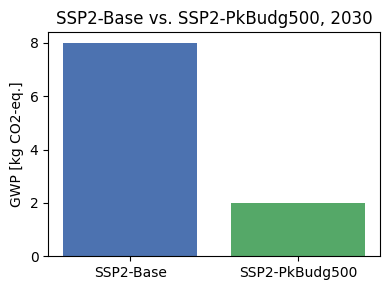

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(comparison.summary["label"], comparison.summary["static_score"], color=["#4c72b0", "#55a868"])
ax.set_ylabel("GWP [kg CO2-eq.]")
ax.set_title("SSP2-Base vs. SSP2-PkBudg500, 2030")
fig.tight_layout()

Two more things `compare()` gives you, for the two situations that
come up once a comparison grows past a couple of rows: keeping the underlying
objects to dig into one result, and not aborting a long sweep over one bad
settings object.

In [14]:
comparison_with_objects = TimexLCA.compare(
    [
        replace(base, scenario={"pathway": "SSP2-Base"}, label="SSP2-Base"),
        replace(base, scenario={"pathway": "SSP2-PkBudg500"}, label="SSP2-PkBudg500"),
    ],
    keep_objects=True,
)

# dig into one result exactly as you would any TimexLCA
comparison_with_objects.objects["SSP2-Base"].timeline.head(2)

2026-08-23 21:01:14.808 | INFO     | bw_timex.timex_lca:__init__:275 - Initializing TimexLCA object...


2026-08-23 21:01:14.809 | INFO     | bw_timex.timex_lca:__init__:305 - Calculating base LCA...


2026-08-23 21:01:14.815 | INFO     | bw_timex.timex_lca:__init__:322 - Collecting node infos...


2026-08-23 21:01:14.817 | INFO     | bw_timex.timex_lca:__init__:334 - Loading node metadata from 4 database(s)...


2026-08-23 21:01:14.817 | INFO     | bw_timex.timex_lca:__init__:371 - TimexLCA initialized.


...

2026-08-23 21:01:14.874 | INFO     | bw_timex.timex_lca:lci:1139 - Calculating dynamic inventory...


2026-08-23 21:01:14.878 | INFO     | bw_timex.timex_lca:run:560 - Step 3/4: Calculating static LCIA...


2026-08-23 21:01:14.879 | INFO     | bw_timex.timex_lca:run:578 - Step 4/4: Skipping dynamic LCIA (disabled).


2026-08-23 21:01:14.879 | INFO     | bw_timex.timex_lca:run:580 - TimexLCA.run() completed successfully.


,hash_producer,time_mapped_producer,date_producer,producer,producer_name,hash_consumer,time_mapped_consumer,date_consumer,consumer,consumer_name,amount,cumulative_amount,temporal_market_shares,temporal_evolution,temporal_evolution_reference
0,2030,349991492885340162,2030-01-01,349991492352663552,electricity,2030,349991492885340163,2030-01-01,349991492885340160,A,10.0,10.0,{'background_2030_ssp2base': 1},None,producer
1,2030,349991492885340163,2030-01-01,349991492885340160,A,2030,-1,2030-01-01,-1,-1,1.0,1.0,None,None,producer


In [15]:
resilient = TimexLCA.compare(
    [
        replace(base, scenario={"pathway": "SSP2-Base"}, label="ok"),
        replace(base, scenario={"pathway": "SSP2-Base"}, label="broken", temporal_grouping="fortnight"),
    ],
    on_error="record",
)

resilient.summary[["label", "static_score", "error"]]

2026-08-23 21:01:14.886 | INFO     | bw_timex.timex_lca:__init__:275 - Initializing TimexLCA object...


2026-08-23 21:01:14.887 | INFO     | bw_timex.timex_lca:__init__:305 - Calculating base LCA...


2026-08-23 21:01:14.892 | INFO     | bw_timex.timex_lca:__init__:322 - Collecting node infos...


2026-08-23 21:01:14.894 | INFO     | bw_timex.timex_lca:__init__:334 - Loading node metadata from 4 database(s)...


2026-08-23 21:01:14.894 | INFO     | bw_timex.timex_lca:__init__:371 - TimexLCA initialized.


...

2026-08-23 21:01:14.920 | INFO     | bw_timex.timex_lca:run:529 - Starting TimexLCA.run() pipeline...


2026-08-23 21:01:14.920 | INFO     | bw_timex.timex_lca:run:536 - Step 1/4: Building timeline...


2026-08-23 21:01:14.921 | WARNING  | bw_timex.timex_lca:compare:717 - Comparison run 'broken' failed: 1 validation error for BuildTimelineInputs
temporal_grouping
  Input should be 'year', 'month', 'day' or 'hour' [type=literal_error, input_value='fortnight', input_type=str]
    For further information visit https://errors.pydantic.dev/2.12/v/literal_error


Starting graph traversal
Calculation count: 1


,label,static_score,error
0,ok,8.0,NaN
1,broken,NaN,ValidationError: 1 validation error for BuildT...


The bad row's `error` names what went wrong instead of stopping the
other 99 calculations in a real sweep. `on_error="raise"` (the default) is
usually what you want interactively, so a typo surfaces immediately.

## One more thing this workflow benefits from

**Unused vintages are pruned automatically.** Only the databases the timeline
actually sources from - plus the dynamic ones and the demand's own - are
loaded into the time-explicit matrices. A vintage that gets no temporal
market share (a 2050 database for a system ending in 2042, or another
project's databases sharing the same project) no longer adds its processes as
unused columns. On a premise EV case study with three unused databases, this
shrank the expanded technosphere from 262,141 to 174,758 columns and `lci()`
from 31.3 s to 23.1 s, with identical scores.

## From scratch: building the background databases with premise

Everything above ran on a dummy system built inline. In practice, the
background databases come from [premise](https://github.com/polca/premise) -
a full copy of ecoinvent per scenario-year, produced from an IAM's output
(here, REMIND-EU's SSP2-NDC pathway). Assuming a brand new project with
nothing in it yet, that's two credentialed steps before any `TimexLCA` code
runs: import ecoinvent, then let premise build each year.

The cell below is **not executed in this notebook** - the credentials are
placeholders, and a real run needs a genuine ecoinvent licence, tens of
minutes, and a few GB of disk per year:

```python
import bw2io as bi

bi.import_ecoinvent_release(
    version="3.12",
    system_model="cutoff",
    username="dummy_ecoinvent_username",
    password="dummy_ecoinvent_password",
)

from premise import NewDatabase

ndb = NewDatabase(
    scenarios=[
        {"model": "remind", "pathway": "SSP2-NDC", "year": year}
        for year in (2020, 2030, 2040, 2050, 2075, 2100)
    ],
    source_db="ecoinvent-3.12-cutoff",
    source_version="3.12",
    key="dummy_premise_decryption_key",  # get this from the premise maintainers
    biosphere_name="ecoinvent-3.12-biosphere",
)
ndb.update()  # apply the IAM-driven changes for every sector
for year in (2020, 2030, 2040, 2050, 2075, 2100):
    ndb.write_brightway25_database(name=f"REMIND-EU_SSP2-NDC_{year}")
```

premise >= 2.4.9.2 writes each database's `representative_time` (and
`iam_model`/`pathway`/`system_model`/`ecoinvent_version`) as it goes, so no
further mapping step is needed - `TimexLCA` finds all of this on its own, the
same as the metadata calls earlier in this notebook. Check the [premise
documentation](https://premise.readthedocs.io/en/latest/) for the exact,
current parameters - they're not repeated verbatim here since this cell isn't
run against a live premise install.

## Running it on a real premise project

This is exactly the situation the sections above prepare for: a project that
already went through that process. `ei312_REMIND_EU` holds ecoinvent 3.12
(cutoff) and REMIND-EU SSP2-NDC databases for 2020, 2030, 2040, 2050, 2075 and
2100, plus a small EV foreground - the same production system used in this
repo's other premise notebooks (`driving` an EV over its lifetime, drawing
30,000 kWh of low-voltage electricity, with production and end-of-life on
top). The only thing missing for `TimexLCA` is telling it that the
foreground is dynamic - one `set_database_metadata` call, same as before:

In [16]:
import bw2data as bd

bd.projects.set_current("ei312_REMIND_EU")

from bw_timex import TimexLCA, TimexLCASettings, set_database_metadata

set_database_metadata("foreground", representative_time="dynamic")

method = ("ecoinvent-3.12", "EF v3.1", "climate change", "global warming potential (GWP100)")
demand = {("foreground", "driving"): 1}

`TimexLCASettings` and `from_settings(...).run()` work exactly as they
did on the dummy system - the only difference is the real background now
carries tens of thousands of activities across six vintages instead of three
dummy ones:

In [17]:
from datetime import datetime

settings = TimexLCASettings(
    demand=demand,
    method=method,
    starting_datetime=datetime(2020, 6, 1),  # the EV is bought and driven from 2020
    dynamic_lcia_enabled=False,
    build_dynamic_biosphere=False,  # only the static score is compared below
    label="bought 2020",
)

tlca = TimexLCA.from_settings(settings).run()
print("base score:  ", tlca.base_score)
print("static score:", tlca.static_score)

2026-08-23 21:01:14.939 | INFO     | bw_timex.timex_lca:__init__:275 - Initializing TimexLCA object...


2026-08-23 21:01:14.940 | INFO     | bw_timex.timex_lca:__init__:305 - Calculating base LCA...


/Users/timodiepers/Documents/Coding/bw_timex/.venv/lib/python3.12/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 3.90e+13)
  warnings.warn(msg, UmfpackWarning)
2026-08-23 21:01:15.640 | INFO     | bw_timex.timex_lca:__init__:322 - Collecting node infos...


2026-08-23 21:01:15.677 | INFO     | bw_timex.timex_lca:__init__:334 - Loading node metadata from 10 database(s)...


2026-08-23 21:01:17.204 | INFO     | bw_timex.timex_lca:__init__:371 - TimexLCA initialized.


...

2026-08-23 21:01:31.629 | INFO     | bw_timex.timex_lca:lci:1139 - Calculating dynamic inventory...


/Users/timodiepers/Documents/Coding/bw_timex/.venv/lib/python3.12/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 1.65e+13)
  warnings.warn(msg, UmfpackWarning)
2026-08-23 21:01:33.460 | INFO     | bw_timex.timex_lca:run:560 - Step 3/4: Calculating static LCIA...


2026-08-23 21:01:33.462 | INFO     | bw_timex.timex_lca:run:578 - Step 4/4: Skipping dynamic LCIA (disabled).


2026-08-23 21:01:33.462 | INFO     | bw_timex.timex_lca:run:580 - TimexLCA.run() completed successfully.


base score:   23247.15112358249
static score: 25462.99744065805


The static score differs from the base score because `driving`'s
30,000 kWh are spread over the vehicle's lifetime, and get resolved against
whichever REMIND-EU vintage each year of use falls into - not just the 2020
one the exchange nominally points at.

(Two warnings are expected here and can be ignored for this comparison:
`bw_temporalis`'s traversal reports a low score-coverage percentage - it only
measures the *foreground* graph it walks, and most of this system's impact
comes from the background, which is resolved by solving the expanded matrix
directly rather than by traversal. And three EV-part productions - glider,
powertrain, battery - only have vintages up to 2040 in this project, from an
older case study; their temporal market falls back to the closest one it has
for later purchase years, while `driving`'s electricity keeps resolving
against the full 2020-2100 range.)

`run()` on the same object, with only `starting_datetime` changed, reuses the
base LCA - and shows how much a 55-year-later purchase benefits from
REMIND-EU's grid decarbonization:

In [18]:
base_lca_id = id(tlca.base_lca)

tlca.run(starting_datetime=datetime(2075, 6, 1))  # same EV, bought decades later
print("static score, bought 2075:", tlca.static_score)
print("base LCA reused:", id(tlca.base_lca) == base_lca_id)

2026-08-23 21:01:33.466 | INFO     | bw_timex.timex_lca:run:529 - Starting TimexLCA.run() pipeline...


2026-08-23 21:01:33.466 | INFO     | bw_timex.timex_lca:run:536 - Step 1/4: Building timeline...


2026-08-23 21:01:33.467 | INFO     | bw_timex.timex_lca:build_timeline:938 - No edge filter function provided. Skipping all edges in background databases.


2026-08-23 21:01:33.467 | INFO     | bw_timex.timex_lca:build_timeline:959 - Creating activity time mapping...


2026-08-23 21:01:33.625 | INFO     | bw_timex.timeline_builder:__init__:113 - Traversing supply chain graph...


...

2026-08-23 21:01:37.372 | INFO     | bw_timex.timex_lca:lci:1139 - Calculating dynamic inventory...


/Users/timodiepers/Documents/Coding/bw_timex/.venv/lib/python3.12/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 2.10e+13)
  warnings.warn(msg, UmfpackWarning)
2026-08-23 21:01:40.088 | INFO     | bw_timex.timex_lca:run:560 - Step 3/4: Calculating static LCIA...


2026-08-23 21:01:40.090 | INFO     | bw_timex.timex_lca:run:578 - Step 4/4: Skipping dynamic LCIA (disabled).


2026-08-23 21:01:40.090 | INFO     | bw_timex.timex_lca:run:580 - TimexLCA.run() completed successfully.


static score, bought 2075: 8375.067003639087
base LCA reused: True
